In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/ai_ml_datasets/weather_prediction" /content/weather_prediction


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout



In [4]:
df=pd.read_csv("/content/weather_prediction/seattle-weather.csv")
df

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...,...
1456,2015-12-27,8.6,4.4,1.7,2.9,rain
1457,2015-12-28,1.5,5.0,1.7,1.3,rain
1458,2015-12-29,0.0,7.2,0.6,2.6,fog
1459,2015-12-30,0.0,5.6,-1.0,3.4,sun


In [5]:
df.columns

Index(['date', 'precipitation', 'temp_max', 'temp_min', 'wind', 'weather'], dtype='object')

In [6]:
# To see if a column contains null value
df.isnull().any()

,0
date,False
precipitation,False
temp_max,False
temp_min,False
wind,False
weather,False


In [7]:
# count the no of null value each column  contains
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


In [8]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [9]:
df['weather'].unique()

array(['drizzle', 'rain', 'sun', 'snow', 'fog'], dtype=object)

In [10]:
df['date'] = pd.to_datetime(df['date'])
df['date']

,date
0,2012-01-01
1,2012-01-02
2,2012-01-03
3,2012-01-04
4,2012-01-05
...,...
1456,2015-12-27
1457,2015-12-28
1458,2015-12-29
1459,2015-12-30


In [11]:
df['month'] = df['date'].dt.month
df['month']

,month
0,1
1,1
2,1
3,1
4,1
...,...
1456,12
1457,12
1458,12
1459,12


In [12]:
df['month'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [13]:
df['season'] = df['month'] % 12 // 3 + 1
df['season']

,season
0,1
1,1
2,1
3,1
4,1
...,...
1456,1
1457,1
1458,1
1459,1


In [14]:
df['season'].unique()

array([1, 2, 3, 4], dtype=int32)

In [15]:
df = df.drop(columns=['date'])
df

,precipitation,temp_max,temp_min,wind,weather,month,season
0,0.0,12.8,5.0,4.7,drizzle,1,1
1,10.9,10.6,2.8,4.5,rain,1,1
2,0.8,11.7,7.2,2.3,rain,1,1
3,20.3,12.2,5.6,4.7,rain,1,1
4,1.3,8.9,2.8,6.1,rain,1,1
...,...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain,12,1
1457,1.5,5.0,1.7,1.3,rain,12,1
1458,0.0,7.2,0.6,2.6,fog,12,1
1459,0.0,5.6,-1.0,3.4,sun,12,1


In [16]:
df = df.drop(columns=['season'])
df

,precipitation,temp_max,temp_min,wind,weather,month
0,0.0,12.8,5.0,4.7,drizzle,1
1,10.9,10.6,2.8,4.5,rain,1
2,0.8,11.7,7.2,2.3,rain,1
3,20.3,12.2,5.6,4.7,rain,1
4,1.3,8.9,2.8,6.1,rain,1
...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain,12
1457,1.5,5.0,1.7,1.3,rain,12
1458,0.0,7.2,0.6,2.6,fog,12
1459,0.0,5.6,-1.0,3.4,sun,12


In [17]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['weather_encoded'] = le.fit_transform(df['weather'])
df['weather_encoded']

,weather_encoded
0,0
1,2
2,2
3,2
4,2
...,...
1456,2
1457,2
1458,1
1459,4


In [18]:
df['weather_encoded'].unique()

array([0, 2, 4, 3, 1])

In [19]:
print(dict(zip(le.classes_, le.transform(le.classes_))))
# Store this in form of list


{'drizzle': np.int64(0), 'fog': np.int64(1), 'rain': np.int64(2), 'snow': np.int64(3), 'sun': np.int64(4)}


In [20]:
classes = list(le.classes_)
encoded_values = list(le.transform(le.classes_))

print(encoded_values)
classes

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


['drizzle', 'fog', 'rain', 'snow', 'sun']

In [21]:
df = df.drop(columns=['weather'])
df

,precipitation,temp_max,temp_min,wind,month,weather_encoded
0,0.0,12.8,5.0,4.7,1,0
1,10.9,10.6,2.8,4.5,1,2
2,0.8,11.7,7.2,2.3,1,2
3,20.3,12.2,5.6,4.7,1,2
4,1.3,8.9,2.8,6.1,1,2
...,...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,12,2
1457,1.5,5.0,1.7,1.3,12,2
1458,0.0,7.2,0.6,2.6,12,1
1459,0.0,5.6,-1.0,3.4,12,4


In [22]:
x=df.drop("weather_encoded",axis=1)
y=df["weather_encoded"]
x


,precipitation,temp_max,temp_min,wind,month
0,0.0,12.8,5.0,4.7,1
1,10.9,10.6,2.8,4.5,1
2,0.8,11.7,7.2,2.3,1
3,20.3,12.2,5.6,4.7,1
4,1.3,8.9,2.8,6.1,1
...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,12
1457,1.5,5.0,1.7,1.3,12
1458,0.0,7.2,0.6,2.6,12
1459,0.0,5.6,-1.0,3.4,12


In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled


array([[-0.45364986, -0.49529914, -0.64421175,  1.01497975, -1.6014511 ],
       [ 1.17859791, -0.79473121, -1.08234662,  0.87583314, -1.6014511 ],
       [-0.33385186, -0.64501518, -0.20607688, -0.65477956, -1.6014511 ],
       ...,
       [-0.45364986, -1.25748987, -1.52048149, -0.44605965,  1.58815364],
       [-0.45364986, -1.47525865, -1.83912504,  0.11052679,  1.58815364],
       [-0.45364986, -1.47525865, -2.05819247,  0.18010009,  1.58815364]])

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42, stratify=y
)


In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [26]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),

    Dense(len(y.unique()), activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
from tensorflow.keras.optimizers import Adam

In [28]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping


In [30]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

In [31]:
EPOCHS = 100

In [32]:
history = model.fit(
    x_train,
    y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.1971 - loss: 1.6097 - val_accuracy: 0.3846 - val_loss: 1.5711
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4495 - loss: 1.5211 - val_accuracy: 0.3846 - val_loss: 1.3560
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4563 - loss: 1.3149 - val_accuracy: 0.3846 - val_loss: 1.1813
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5107 - loss: 1.1775 - val_accuracy: 0.6752 - val_loss: 1.0114
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5906 - loss: 1.1038 - val_accuracy: 0.7650 - val_loss: 0.8290
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7074 - loss: 0.9390 - val_accuracy: 0.7778 - val_loss: 0.7212
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7153 - loss: 0.8714 - val_accuracy: 0.7692 - val_loss: 0.7188
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7279 - loss: 0.8498 - val_accuracy: 0.

In [33]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8169 - loss: 0.5916 
Test Accuracy: 0.8259385824203491


In [34]:
history.params

{'verbose': 'auto', 'epochs': 200, 'steps': 15}

In [35]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [36]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

print("accuracy",acc)
print("validation accuracy",val_acc)
print("loss",loss)
print("validation loss",val_loss)

accuracy [0.31477516889572144, 0.44967880845069885, 0.45610278844833374, 0.5342612266540527, 0.6349036693572998, 0.7012848258018494, 0.7194860577583313, 0.7259100675582886, 0.7355460524559021, 0.7237687110900879, 0.7387580275535583, 0.7323340177536011, 0.7483940124511719, 0.7430406808853149, 0.762312650680542, 0.7483940124511719, 0.7526766657829285, 0.7548179626464844, 0.7473233342170715, 0.7505353093147278, 0.7580299973487854, 0.7516059875488281, 0.7569593191146851, 0.759100615978241, 0.7612419724464417, 0.7580299973487854, 0.7655246257781982, 0.7516059875488281, 0.7558886408805847, 0.7548179626464844, 0.7805139422416687, 0.7558886408805847, 0.7698072791099548, 0.7773019075393677, 0.7698072791099548, 0.7633832693099976, 0.7708779573440552, 0.7569593191146851, 0.7719486355781555, 0.778372585773468, 0.7687366008758545, 0.7730192542076111, 0.7708779573440552, 0.7847965955734253, 0.778372585773468, 0.7687366008758545, 0.7751606106758118, 0.7687366008758545, 0.7762312889099121, 0.788008570

In [37]:
epochs_range = range(len(acc))

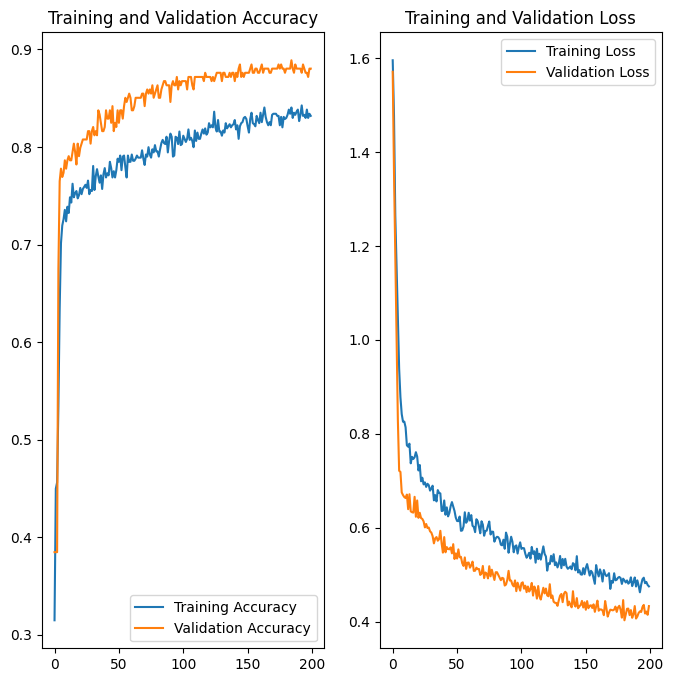

In [38]:

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training Loss')
plt.plot(epochs_range,val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [39]:
# Save the model in h5 format in /content/drive/MyDrive/ai_ml_model
model.save("/content/drive/MyDrive/ai_ml_model/weather_prediction.h5")

# Save the scaler in pkl format in /content/drive/MyDrive/ai_ml_model
import pickle
pickle.dump(scaler, open('/content/drive/MyDrive/ai_ml_model/scaler.pkl', 'wb'))